In [1]:
import pandas as pd


In [3]:
apps=pd.read_csv("apps.csv")

In [4]:
user_reviews=pd.read_csv("user_reviews.csv")

In [5]:
print(apps.head())

   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644  25.0  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967   2.8     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  Art & Design;Pretend Play  J

In [6]:
print(apps.info())

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB
None


In [7]:
print(user_reviews.head())

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  


In [8]:
print(user_reviews.info())

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB
None


In [10]:
apps.drop_duplicates(inplace=True)

In [11]:
apps['Installs'] = apps['Installs'].str.replace('+','', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',','', regex=False)
apps['Installs'] = apps['Installs'].astype(int)

In [12]:
apps['Price'] = apps['Price'].str.replace('$','', regex=False).astype(float)

In [14]:
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

In [15]:
apps['Category'].value_counts().head(10)

Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64

In [16]:
apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

Category
EVENTS                 4.395313
EDUCATION              4.363866
ART_AND_DESIGN         4.354687
BOOKS_AND_REFERENCE    4.334234
PERSONALIZATION        4.325532
PARENTING              4.300000
BEAUTY                 4.283019
SOCIAL                 4.255230
HEALTH_AND_FITNESS     4.251736
GAME                   4.249948
Name: Rating, dtype: float64

In [17]:
apps.groupby('Type')['Installs'].mean()

Type
Free    8.431492e+06
Paid    7.587947e+04
Name: Installs, dtype: float64

In [18]:
apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

Category
GAME                  13878924415
COMMUNICATION         11038276251
TOOLS                  8001771915
PRODUCTIVITY           5793091369
SOCIAL                 5487867902
PHOTOGRAPHY            4649147655
FAMILY                 4427941505
VIDEO_PLAYERS          3926902720
TRAVEL_AND_LOCAL       2894887146
NEWS_AND_MAGAZINES     2369217760
Name: Installs, dtype: int64

In [19]:
apps.groupby('Type')['Installs'].sum()

Type
Free    75065572646
Paid       57364881
Name: Installs, dtype: int64

In [20]:
apps[['Rating', 'Installs']].corr()

,Rating,Installs
Rating,1.000000,0.034307
Installs,0.034307,1.000000


In [22]:
apps.sort_values(by='Price', ascending=False).head(10)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3469,4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3,10000,Paid,400.00,Everyone,Lifestyle,"May 3, 2018",1.0.1,4.1 and up
8780,9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,4.3,0,40.0,0,Paid,399.99,Everyone,Lifestyle,"December 1, 2017",MONEY,4.1 and up
4398,5354,I am Rich Plus,FAMILY,4.0,856,8.7,10000,Paid,399.99,Everyone,Entertainment,"May 19, 2018",3,4.4 and up
4396,5351,I am rich,LIFESTYLE,3.8,3547,1.8,100000,Paid,399.99,Everyone,Lifestyle,"January 12, 2018",2,4.0.3 and up
4413,5369,I am Rich,FINANCE,4.3,180,3.8,5000,Paid,399.99,Everyone,Finance,"March 22, 2018",1,4.2 and up
4417,5373,I AM RICH PRO PLUS,FINANCE,4.0,36,41.0,1000,Paid,399.99,Everyone,Finance,"June 25, 2018",1.0.2,4.1 and up
3327,4197,most expensive app (H),FAMILY,4.3,6,1.5,100,Paid,399.99,Everyone,Entertainment,"July 16, 2018",1,7.0 and up
4403,5359,I am rich(premium),FINANCE,3.5,472,1.0,5000,Paid,399.99,Everyone,Finance,"May 1, 2017",3.4,4.4 and up
4406,5362,I Am Rich Pro,FAMILY,4.4,201,2.7,5000,Paid,399.99,Everyone,Entertainment,"May 30, 2017",1.54,1.6 and up
4400,5356,I Am Rich Premium,FINANCE,4.1,1867,4.7,50000,Paid,399.99,Everyone,Finance,"November 12, 2017",1.6,4.0 and up


In [24]:
apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

Category
EVENTS                 4.395313
EDUCATION              4.363866
ART_AND_DESIGN         4.354687
BOOKS_AND_REFERENCE    4.334234
PERSONALIZATION        4.325532
PARENTING              4.300000
BEAUTY                 4.283019
SOCIAL                 4.255230
HEALTH_AND_FITNESS     4.251736
GAME                   4.249948
Name: Rating, dtype: float64

In [25]:
apps.groupby('Category')['Price'].mean().sort_values(ascending=False).head(10)

Category
FINANCE                8.408203
LIFESTYLE              6.398022
MEDICAL                2.520759
EVENTS                 1.718594
FAMILY                 1.309967
PRODUCTIVITY           0.670936
BOOKS_AND_REFERENCE    0.539505
PHOTOGRAPHY            0.420925
BUSINESS               0.417357
WEATHER                0.410380
Name: Price, dtype: float64

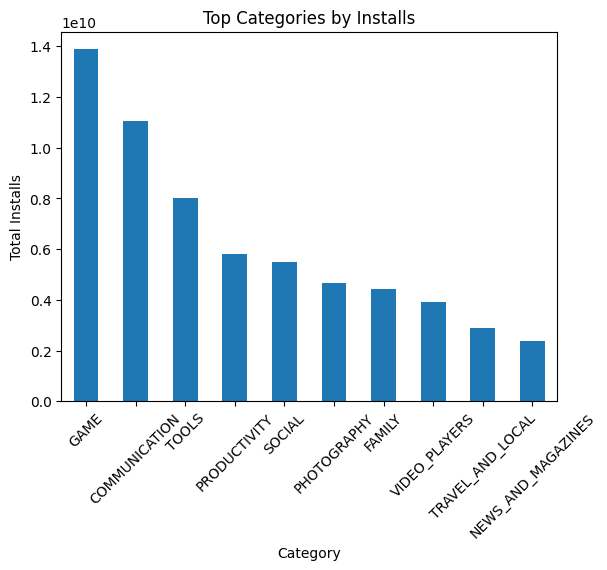

In [26]:
import matplotlib.pyplot as plt

top_cat = apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

top_cat.plot(kind='bar')
plt.title("Top Categories by Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)
plt.show()

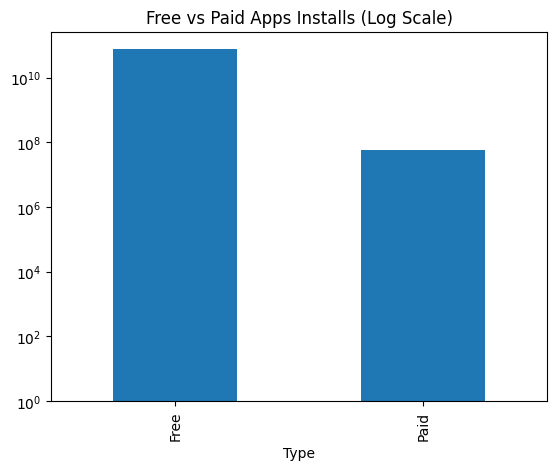

In [30]:
apps.groupby('Type')['Installs'].sum().plot(kind='bar', log=True)
plt.title("Free vs Paid Apps Installs (Log Scale)")
plt.show()

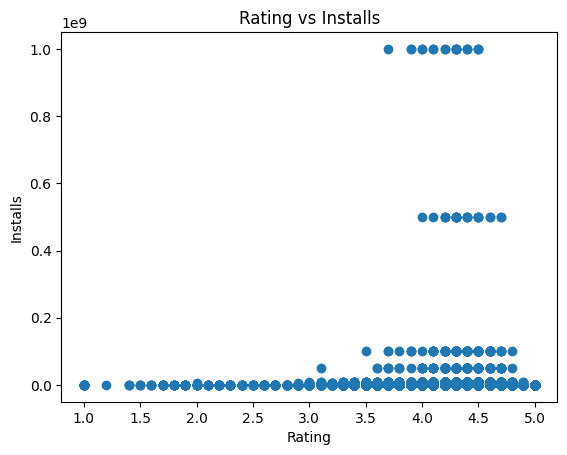

In [28]:
plt.scatter(apps['Rating'], apps['Installs'])
plt.xlabel("Rating")
plt.ylabel("Installs")
plt.title("Rating vs Installs")
plt.show()

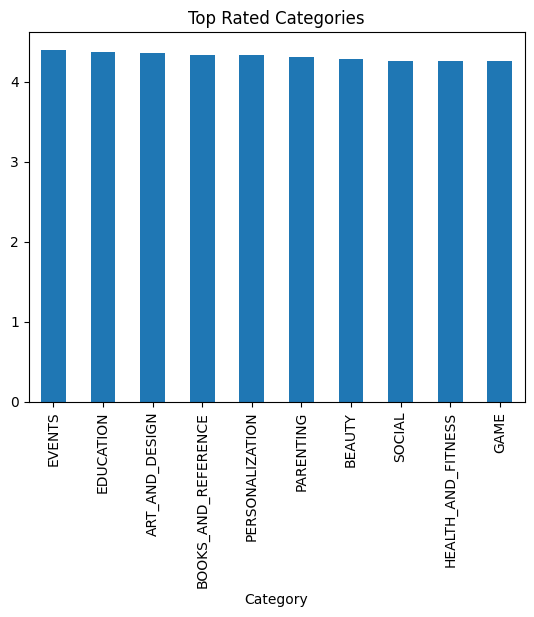

In [29]:
apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Rated Categories")
plt.show()